In [13]:
import onnx
from onnx import helper, numpy_helper
import numpy as np
import pandas as pd
import joblib

In [ ]:
embedding_weights

In [24]:
import onnx
import numpy as np
import pandas as pd
import joblib
from onnx import numpy_helper

# 1. Caminhos dos arquivos
caminho_modelo = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\model\melhor_modelo_producao.onnx"
caminho_mappings = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\artifacts\mappings_v1.joblib"

print("Carregando modelo ONNX e mapeamentos...")
model_onnx = onnx.load(caminho_modelo)
mappings = joblib.load(caminho_mappings)

print("Chaves encontradas no mappings:", mappings.keys())

# 2. Função ajustada para buscar pelo nome exato do tensor
def processar_e_salvar_embeddings(nome_tensor_alvo, chave_mapping, nome_saida):
    print(f"\n--- Processando Embeddings de: {nome_saida} ---")
    
    matriz_pesos = None
    for init in model_onnx.graph.initializer:
        if init.name == nome_tensor_alvo:
            matriz_pesos = numpy_helper.to_array(init)
            print(f"Tensor encontrado: {init.name} | Shape: {matriz_pesos.shape}")
            break
            
    if matriz_pesos is None:
        print(f"⚠️ Tensor '{nome_tensor_alvo}' não foi encontrado no ONNX.")
        return

    # Pega o dicionário do joblib
    vocab_dict = mappings.get(chave_mapping)
    if vocab_dict is None:
        print(f"⚠️ Chave '{chave_mapping}' não encontrada no arquivo joblib.")
        return

    # Inverte o dicionário para mapear ID -> Nome do Material
    id_para_nome = {v: k for k, v in vocab_dict.items()}
    
    nomes_materiais = []
    for i in range(len(matriz_pesos)):
        nomes_materiais.append(id_para_nome.get(i, f"Desconhecido_{i}"))

    # Cria o DataFrame e salva
    df_embeddings = pd.DataFrame(matriz_pesos)
    df_embeddings.insert(0, 'material', nomes_materiais)
    
    nome_arquivo = f"embeddings_{nome_saida}.csv"
    df_embeddings.to_csv(nome_arquivo, index=False)
    print(f"✅ Salvo com sucesso em: {nome_arquivo}")

# 3. Executando com os nomes exatos descobertos
processar_e_salvar_embeddings('emb_base.weight', 'material_base', 'base')
processar_e_salvar_embeddings('emb_add.weight', 'material_adicao', 'adicao')

Carregando modelo ONNX e mapeamentos...
Chaves encontradas no mappings: dict_keys(['material_base', 'material_adicao', 'vocab_sizes'])

--- Processando Embeddings de: base ---
Tensor encontrado: emb_base.weight | Shape: (72, 8)
✅ Salvo com sucesso em: embeddings_base.csv

--- Processando Embeddings de: adicao ---
Tensor encontrado: emb_add.weight | Shape: (73, 8)
✅ Salvo com sucesso em: embeddings_adicao.csv


In [58]:
df_base = pd.read_csv("embeddings_base.csv")
df_adicao = pd.read_csv("embeddings_adicao.csv")
 
df_b = df_base.select_dtypes(include=["number"])
df_a = df_adicao.select_dtypes(include=["number"])

emb_cols = [c for c in df_b.columns if c not in ("material", "tipo")]
X = df_b[emb_cols].values
Y = df_a[emb_cols].values
 
print(f"Total de materiais: {X.shape[0]}, dimensões do embedding: {X.shape[1]}")

Total de materiais: 72, dimensões do embedding: 8


In [73]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
Y_pca = pca.fit_transform(df_a)
print(f"Variância explicada pelo PCA (3 comp.): {pca.explained_variance_ratio_.sum():.2%}")
X_pca = pca.fit_transform(df_b)
print(f"Variância explicada pelo PCA (3 comp.): {pca.explained_variance_ratio_.sum():.2%}")

Variância explicada pelo PCA (3 comp.): 37.95%
Variância explicada pelo PCA (3 comp.): 38.72%


In [68]:
from sklearn.manifold import TSNE
perplexity = min(30, max(5, X.shape[0] // 4))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto",
)
Y_tsne = tsne.fit_transform(df_a)
print(f"KL divergence final: {tsne.kl_divergence_:.4f}")
X_tsne = tsne.fit_transform(df_b)
print(f"KL divergence final: {tsne.kl_divergence_:.4f}")
from sklearn.manifold import trustworthiness
score = trustworthiness(X, X_tsne, n_neighbors=5)
print(f"Trustworthiness: {score:.4f}")
score2 = trustworthiness(Y, Y_tsne, n_neighbors=5)
print(f"Trustworthiness: {score2:.4f}")

KL divergence final: 0.6122
KL divergence final: 0.6094
Trustworthiness: 0.9128
Trustworthiness: 0.9073


In [71]:
import umap
n_neighbors = min(15, max(2, X.shape[0] - 1))
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=0.1,
    random_state=42,
)
X_umapb = reducer.fit_transform(df_b)
X_umapa = reducer.fit_transform(df_a)

c:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [72]:
from sklearn.manifold import trustworthiness
score = trustworthiness(X, X_umapb, n_neighbors=5)
print(f"Trustworthiness: {score:.4f}")
score2 = trustworthiness(Y, X_umapa, n_neighbors=5)
print(f"Trustworthiness: {score2:.4f}")

Trustworthiness: 0.8616
Trustworthiness: 0.8721


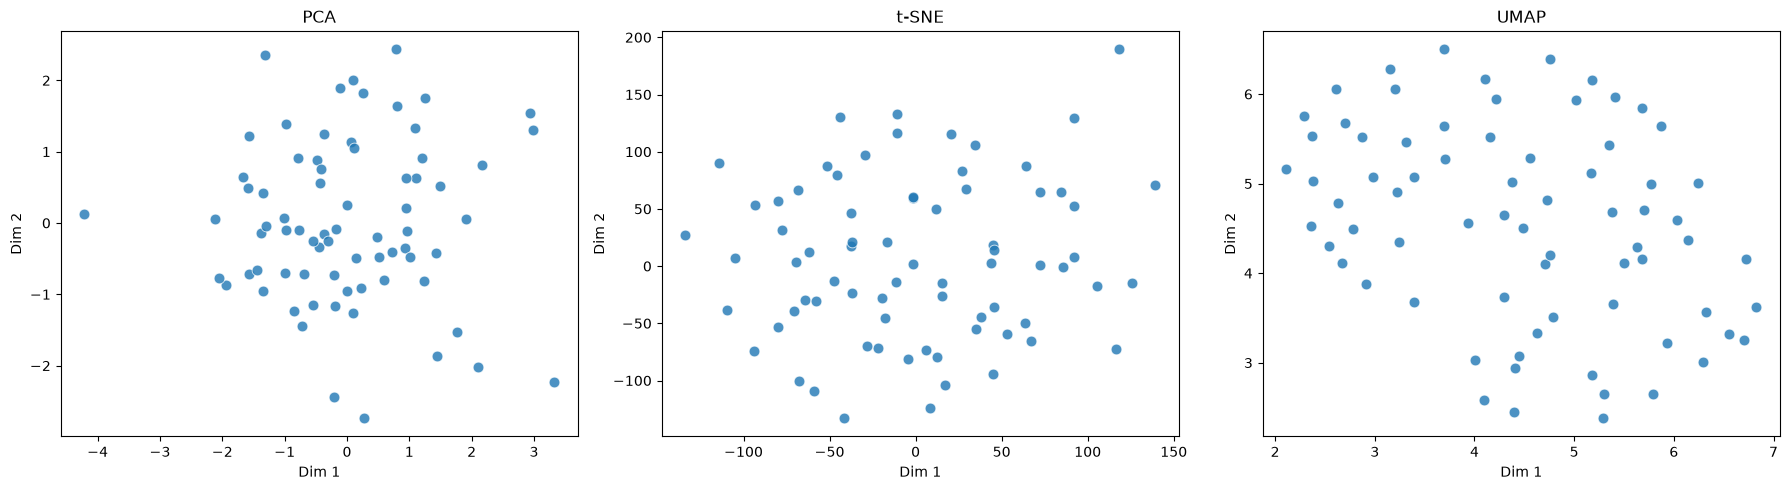

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metodos = [(X_pca, "PCA"), (X_tsne, "t-SNE"), (X_umapb, "UMAP")]

for ax, (X_proj, titulo) in zip(axes, metodos):
    sns.scatterplot(
        x=X_proj[:, 0], y=X_proj[:, 1],
        color="tab:blue",
        s=60, alpha=0.8,
        ax=ax,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

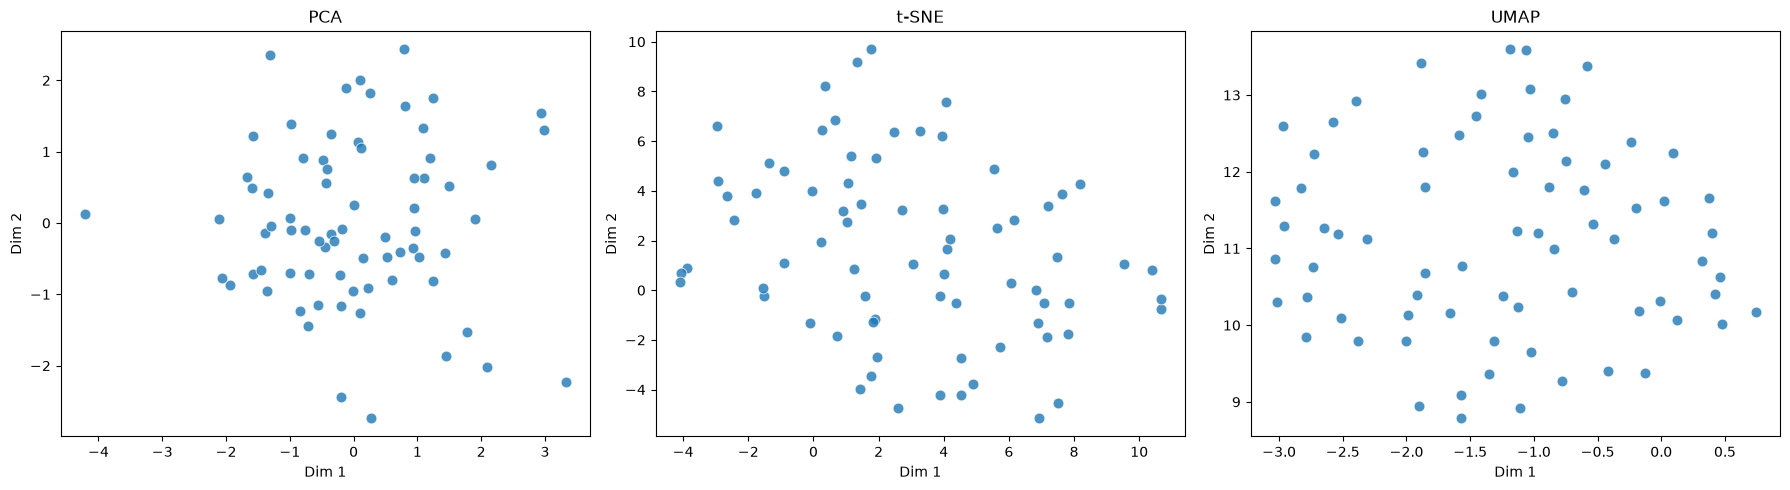

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metodos = [(Y_pca, "PCA"), (Y_tsne, "t-SNE"), (X_umapa, "UMAP")]

for ax, (X_proj, titulo) in zip(axes, metodos):
    sns.scatterplot(
        x=X_proj[:, 0], y=X_proj[:, 1],
        color="tab:blue",
        s=60, alpha=0.8,
        ax=ax,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

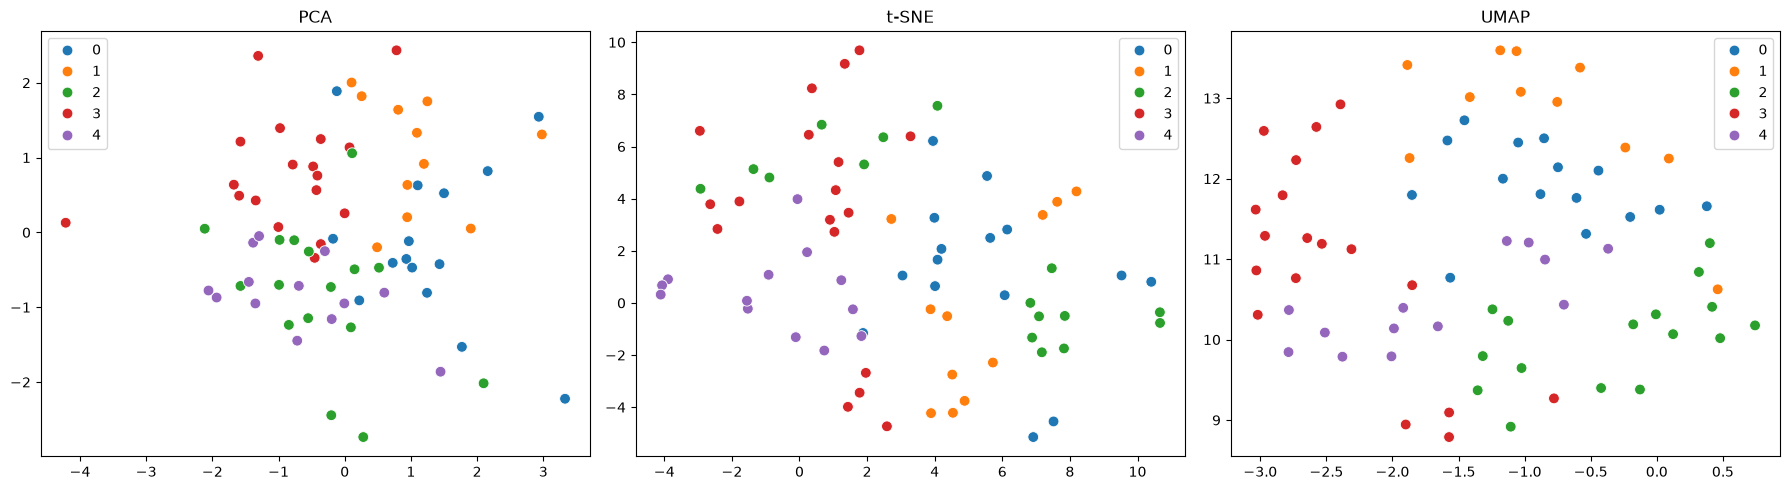

In [92]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_a)  # nos dados originais 8D, não no X_pca/tsne/umap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (X_proj, titulo) in zip(axes, metodos):
    sns.scatterplot(x=X_proj[:, 0], y=X_proj[:, 1], hue=clusters, palette="tab10", s=60, ax=ax)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()